In [1]:
import pandas as pd
import numpy as np

In [2]:
# SFMS
slope = 0.86
intercept=-8.5
def del_SFMS(Mstar, SFR):
    SFMS = slope * Mstar + intercept
    del_SFMS = SFR - SFMS
    return del_SFMS

def is_quenched(del_SFMS):
    if del_SFMS < -0.5:
        return True
    else:
        return False

In [3]:
high_mass_satellite_df = pd.read_parquet ('../../data/high_mass_satellite_df_annuli_revised.parquet')
print('length of high- mass satellites df:', len(high_mass_satellite_df))

# --- remove quenched galaxies using del_SFMS and is_quenched ---
# del_SFMS takes (Mstar, SFR) -> use 's_mass' and 'global_SFRs' columns
high_mass_satellite_df['del_SFMS'] = del_SFMS(high_mass_satellite_df['s_mass'], high_mass_satellite_df['global_SFRs'])

# is_quenched expects the del_SFMS value
quenched_mask = high_mass_satellite_df['del_SFMS'].apply(is_quenched)
removed = quenched_mask.sum()
high_mass_satellite_df = high_mass_satellite_df[~quenched_mask].reset_index(drop=True)
print(f"Removed {removed} quenched rows; remaining {len(high_mass_satellite_df)} rows.")

# drop helper column
high_mass_satellite_df = high_mass_satellite_df.drop(columns=['del_SFMS'])
print(f"filtered dataframe has {len(high_mass_satellite_df)} rows.")

length of high- mass satellites df: 8675
Removed 2883 quenched rows; remaining 5792 rows.
filtered dataframe has 5792 rows.


In [4]:
high_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,12.0,0.102668,9.945001,-2.064797,7.581160,0,0.0,8.373481,0.025639,1,140.284103,0.092235,6.864844e+06,0.0,38878.035156,79.801081,0.908204,0.000000,6.864844e+06
1,12.0,0.308004,9.515790,-2.467576,7.064412,1,0.0,8.373481,0.025639,1,140.284103,0.092235,6.864844e+06,0.0,38878.035156,79.801081,0.908204,0.000000,6.864844e+06
2,12.0,0.513341,9.033496,-2.950103,6.416259,1,0.0,8.373481,0.025639,1,140.284103,0.092235,6.864844e+06,0.0,38878.035156,79.801081,0.908204,0.000000,6.864844e+06
3,12.0,0.718677,8.695794,-3.298430,6.233654,1,0.0,8.373481,0.025639,1,140.284103,0.092235,6.864844e+06,0.0,38878.035156,79.801081,0.908204,0.000000,6.864844e+06
4,12.0,0.924013,8.463589,-3.556194,6.241119,1,0.0,8.373481,0.025639,1,140.284103,0.092235,6.864844e+06,0.0,38878.035156,79.801081,0.908204,0.000000,6.864844e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,476528.0,0.179965,9.485483,-2.459436,7.232764,1,0.0,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
5788,476528.0,0.539895,9.195900,-2.790333,6.889097,1,0.0,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
5789,476528.0,0.899825,8.818249,-3.192451,6.611662,1,0.0,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
5790,476528.0,1.259755,8.497334,-3.498477,6.271559,1,0.0,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06


In [5]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_satellite_df['SFE'] = 10**(low_mass_satellite_df['avg_SFR'] - low_mass_satellite_df['avg_gas_mass'])
# low_mass_satellite_df['f_gas'] = 10**(low_mass_satellite_df['avg_gas_mass'] - low_mass_satellite_df['avg_s_mass'])

In [6]:
# # remove the rows where the sfr_indicator is 0.0 -> implies artificially imposed minimum
# low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['sfr_indicator'] != 0.0]
# low_mass_satellite_df

In [7]:
# star forming quenching vector value = 0
high_mass_satellite_df = high_mass_satellite_df[high_mass_satellite_df['quenching_vector'] != 1]
high_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,12.0,0.102668,9.945001,-2.064797,7.581160,0,0.000000,8.373481,0.025639,1,140.284103,0.092235,6.864844e+06,0.000000e+00,38878.035156,79.801081,0.908204,0.000000,6.864844e+06
9,13.0,0.139092,10.290051,-1.707634,7.491164,0,0.000000,9.707414,0.037718,1,148.034866,0.103584,1.082431e+07,1.769249e-320,38878.035156,229.974866,0.276365,0.000000,1.082431e+07
16,15.0,0.136624,9.873816,-2.142322,7.079582,0,0.000000,7.153849,0.016255,1,137.313675,0.081915,8.164414e+06,0.000000e+00,38878.035156,931.601722,0.413027,0.756453,8.164414e+06
23,16.0,0.116108,9.999896,-2.021999,7.823506,0,0.000000,10.057720,0.020074,1,133.630646,0.082284,1.126167e+07,0.000000e+00,38878.035156,103.127956,0.868439,0.081201,1.126167e+07
43,18.0,0.869984,8.172646,-3.184762,6.257542,0,5.379467,8.614480,0.011003,1,111.129562,0.024162,3.144018e+06,0.000000e+00,38878.035156,56.545641,0.833715,0.255279,3.144018e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5782,462987.0,0.173652,9.171778,-0.202319,8.651024,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,7.552357e+01,0.000000e+00,129.809052,0.046284,-1.015946,0.104524,7.552357e+01
5783,462987.0,0.520957,8.854676,-0.765807,8.399230,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,7.552357e+01,0.000000e+00,129.809052,0.046284,-1.015946,0.104524,7.552357e+01
5784,462987.0,0.868261,8.582487,-1.080499,8.100421,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,7.552357e+01,0.000000e+00,129.809052,0.046284,-1.015946,0.104524,7.552357e+01
5785,462987.0,1.215566,8.400651,-1.433384,7.964696,0,0.000000,2.001361,0.003254,1,83.934608,2.233273,7.552357e+01,0.000000e+00,129.809052,0.046284,-1.015946,0.104524,7.552357e+01


In [8]:
high_mass_satellite_df.shape

(2927, 19)

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
high_mass_satellite_df = high_mass_satellite_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "gas_mass","avg_gas_mass", "quenching_vector", "Bfld", "veldisp", "BH_AGN", "bulge"])

<Axes: >

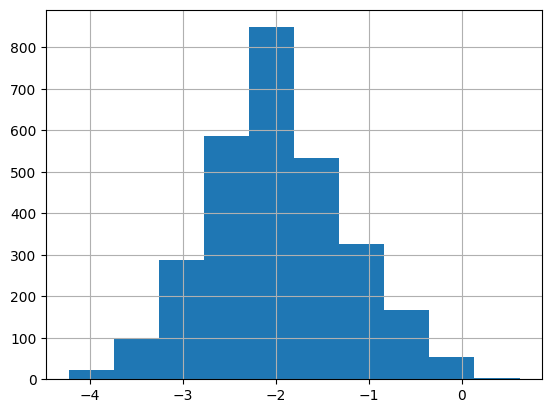

In [10]:
high_mass_satellite_df['avg_SFR'].hist()

In [11]:
# this indicates that there are more instances of the delta rate on the left

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

galaxy_ids = high_mass_satellite_df['subID']

feature_importances_list = []
feature_names = None
test_mses = []
train_mses = []


for seed in range(10):
    # split galaxies into 50% training and 50% testing
    unique_galaxies = np.unique(high_mass_satellite_df['subID'])
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    # assign spaxels based on galaxy split
    train_data = high_mass_satellite_df[high_mass_satellite_df['subID'].isin(train_galaxies)]
    test_data = high_mass_satellite_df[high_mass_satellite_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['avg_SFR', 'subID']), train_data['avg_SFR']
    X_test, y_test = test_data.drop(columns=['avg_SFR', 'subID']), test_data['avg_SFR']
    
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    # XGBoost Regressor
    xgb_regressor = XGBRegressor(random_state=seed, n_jobs=-1)

    param_grid = {
    'n_estimators': [100,150,200,250],
    'max_depth': [1],
    'learning_rate': [0.01],
    'subsample': [0.5,0.6, 0.7],
    'colsample_bytree': [1.0],
    'min_child_weight': [20, 25, 30],
    'alpha': [8, 12, 15],
    'lambda': [15, 20, 25]#, 30, 35]
    }
    """
    param_grid = {
    'n_estimators': [600],
    'max_depth': [2],
    'learning_rate': [0.006],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [1.0],
    'min_child_weight': [30, 40, 50],
    'alpha': [3, 4, 5],
    'lambda': [2, 3, 4],
    }
    """

    grid_search = GridSearchCV(
    estimator=xgb_regressor, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1, 
    verbose=2
    )

    grid_search.fit(X_train_scaled, y_train)

    best_xg_regressor = grid_search.best_estimator_
    print(f"Best parameters for seed {seed+1}: {grid_search.best_params_}")

    best_xg_regressor.fit(X_train_scaled, y_train)
    
    y_train_pred = best_xg_regressor.predict(X_train_scaled)
    y_test_pred = best_xg_regressor.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}, Gap= {test_mse - train_mse:.4f}")
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    feature_importances_list.append(best_xg_regressor.feature_importances_)
#     print(random_search.best_params_)
    #print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

print("\nAverage MSE over 10 runs:")
print(f"Train MSE: Mean = {np.mean(train_mses):.4f}, Std = {np.std(train_mses):.4f}")
print(f"Test MSE:  Mean = {np.mean(test_mses):.4f}, Std = {np.std(test_mses):.4f}")


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for seed 1: {'alpha': 8, 'colsample_bytree': 1.0, 'lambda': 15, 'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 20, 'n_estimators': 250, 'subsample': 0.7}
Run 1: Train MSE = 0.3876, Test MSE = 0.3582, Gap= -0.0294
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for seed 2: {'alpha': 8, 'colsample_bytree': 1.0, 'lambda': 15, 'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 20, 'n_estimators': 250, 'subsample': 0.7}
Run 2: Train MSE = 0.3382, Test MSE = 0.4017, Gap= 0.0635
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for seed 3: {'alpha': 8, 'colsample_bytree': 1.0, 'lambda': 15, 'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 20, 'n_estimators': 250, 'subsample': 0.7}
Run 3: Train MSE = 0.3100, Test MSE = 0.4329, Gap= 0.1230
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for see


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
1  avg_s_mass         0.607782  0.067598
3      BHMass         0.333204  0.050713
2      s_mass         0.033033  0.066377
0   bin_radii         0.018124  0.054371
5    overdens         0.007858  0.023573
4       Mhalo         0.000000  0.000000


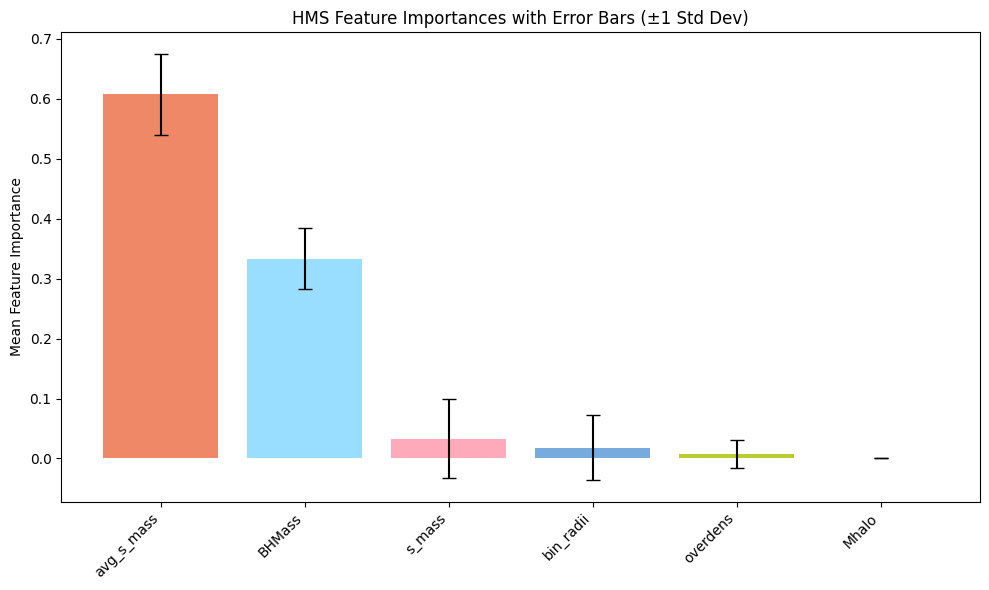

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("HMS Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [28]:
high_mass_satellite_df.corr()

,subID,bin_radii,avg_s_mass,avg_SFR,s_mass,BHMass,Mhalo,overdens
subID,1.000000,0.041594,-0.088382,0.097198,-0.268203,-0.287018,-0.828613,-0.104953
bin_radii,0.041594,1.000000,-0.849805,-0.444657,0.032382,-0.013575,-0.054423,-0.005207
avg_s_mass,-0.088382,-0.849805,1.000000,0.483135,0.096582,0.156639,0.106060,0.045773
avg_SFR,0.097198,-0.444657,0.483135,1.000000,-0.176791,-0.190733,-0.060523,0.063742
s_mass,-0.268203,0.032382,0.096582,-0.176791,1.000000,0.802126,0.138377,0.400774
BHMass,-0.287018,-0.013575,0.156639,-0.190733,0.802126,1.000000,0.167669,0.309009
Mhalo,-0.828613,-0.054423,0.106060,-0.060523,0.138377,0.167669,1.000000,0.004569
overdens,-0.104953,-0.005207,0.045773,0.063742,0.400774,0.309009,0.004569,1.000000


In [29]:
import os
# Define your directory and file name
directory = 'xg_regression_outputs'
filename = 'hms_xg_reg.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to xg_regression_outputs\hms_xg_reg.csv


In [30]:
train_mean = round(np.mean(train_mses), 2)
test_mean = round(np.mean(test_mses), 2)

df = pd.DataFrame({
    'Train MSE': [train_mean],
    'Test MSE': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'xg_regression_outputs'
filename = 'hms_xg_reg_mse.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

   Train MSE  Test MSE
0       0.35      0.38
DataFrame saved to xg_regression_outputs\hms_xg_reg_mse.csv
